# Cornerstone Si_220nm_passive — Technology Demo

In this notebook, we will load the Cornerstone Si_220nm_passive PDK and inspect the process by looking at the cross-section of the extruded geometry.

Source PDK: https://github.com/cornerstone-uos/cornerstone-pdk

## Loading the Cornerstone PDK

In [1]:
# Make `cornerstone_forge` importable when running this notebook in-place
# (i.e. without `pip install -e ../`). Skip if you've installed the package.
import sys, pathlib
_repo = pathlib.Path().resolve().parent
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

import tidy3d as td
import matplotlib.pyplot as plt
import photonforge as pf

import cornerstone_forge as cf

td.config.logging_level = "ERROR"


22:10:52 EDT WARNING: Using canonical configuration directory at                
             '/Users/prash_flexcompute/.config/tidy3d'. Found legacy directory  
             at '~/.tidy3d', which will be ignored. Remove it manually or run   
             'tidy3d config migrate --delete-legacy' to clean up.               

Inspect what's available in the package.

In [2]:
dir(cf)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_yaml_loader',
 'component',
 'list_components',
 'si220_passive',
 'technology']

Load the technology and set it as the default. The factory accepts tunable knobs for the substrate, top oxide, and metal stack — we pass `include_substrate=True` so the BOX appears in the cross-section.

In [3]:
tech = cf.si220_passive(include_substrate=True)
pf.config.default_technology = tech
print(f"{tech.name} v{tech.version}")


Cornerstone Si_220nm_passive v0.1.0


## Inspecting the PDK

Layers, port specs, and extrusion recipes are accessible directly from the technology object.

In [4]:
tech.layers

Name,Layer,Description,Color,Pattern
Si_Etch2_LF_120nm,"(3, 0)",Waveguide,#0080ff18,\
Si_Etch2_DF_120nm,"(4, 0)",Waveguide,#80c0ff18,\\
Si_Etch3_LF_100nm_to_BOX,"(5, 0)",Waveguide,#a080ff18,:
Si_Etch1_DUV_DF_70nm,"(6, 0)",Etch,#ff444418,/
Heat_Fil_LF,"(39, 0)",Metal,#ebc63418,xx
Heat_CP_LF,"(41, 0)",Metal,#c0c0c018,xx
Si_Etch0_EBL_DF_94nm,"(60, 0)",Etch,#ff800018,/
Floorplan,"(99, 0)",Misc,#80808018,hollow
Label_Etch_DF,"(100, 0)",Misc,#a0a0a018,/


In [5]:
tech.ports

Name,Classification,Description,Width (μm),Limits (μm),Radius (μm),Modes,Target n_eff,Path profiles (μm),Voltage path,Current path
rib_1310nm_TE,optical,"Rib TE 1310 nm, w=400 nm core /…… 10.4 um slab",4,"-1, 1.22",0,1 (TE),3,"'Si_Etch2_LF_120nm':…… 0.4, 'Si_Etch3_LF_100nm_to_BOX': 10.4",,
rib_1550nm_TE,optical,"Rib TE 1550 nm, w=450 nm core /…… 10.45 um slab",4,"-1, 1.22",0,1 (TE),2.7,"'Si_Etch2_LF_120nm':…… 0.45, 'Si_Etch3_LF_100nm_to_BOX': 10.45",,
strip_1310nm,optical,"Strip TE/TM 1310 nm, w=400 nm",2,"-1, 1.22",0,2,2.8,'Si_Etch2_LF_120nm':…… 0.4,,
strip_1550nm,optical,"Strip TE/TM 1550 nm, w=450 nm",2.5,"-1, 1.22",0,2,2.5,'Si_Etch2_LF_120nm':…… 0.45,,


In [6]:
tech.extrusion_specs

#,Mask,Limits (μm),Sidewal (°),Opt. Medium,Elec. Medium
0,(),"-inf, -3",0,cSi_Li1993_293K,Si
1,'Si_Etch2_LF_120nm' -…… ('Si_Etch0_EBL_DF_94nm' + 'Si_Etch1_DUV_DF_70nm'),"0, 0.22",0,cSi_Li1993_293K,Si
2,'Si_Etch2_LF_120nm' *…… 'Si_Etch0_EBL_DF_94nm',"0, 0.125",0,cSi_Li1993_293K,Si
3,'Si_Etch2_LF_120nm' *…… 'Si_Etch1_DUV_DF_70nm',"0, 0.15",0,cSi_Li1993_293K,Si
4,'Si_Etch3_LF_100nm_to_……BOX' - 'Si_Etch2_LF_120nm',"0, 0.1",0,cSi_Li1993_293K,Si
5,'Heat_Fil_LF',"2.22, 2.37",0,Ti_Werner2009,"LossyMetalMedium(conductivity=……2.5, fit_param={'attrs': {}, 'max_num_poles': 16, 'tolerance_rms': 0.001, 'frequency_sampling_points': 20, 'log_sampling': True, 'type': 'SurfaceImpedanceFitterParam'}, frequency_range=(100000000.0, 200000000000.0))"
6,'Heat_CP_LF',"2.47, 2.69",0,Al_Rakic1995,"LossyMetalMedium(conductivity=……37.7, fit_param={'attrs': {}, 'max_num_poles': 16, 'tolerance_rms': 0.001, 'frequency_sampling_points': 20, 'log_sampling': True, 'type': 'SurfaceImpedanceFitterParam'}, frequency_range=(100000000.0, 200000000000.0))"


## Cross-section visualization

We build a small reference component that places one rectangle per layer combination — one slot for a strip waveguide, one for a rib (core + slab), one for each grating type, and slots for the heater + contact pad. A single `pf.tidy3d_plot` cross-section at x=0 then shows every extruded medium in one figure.

In [7]:
# Reference component: one feature per layer combination
ref = pf.Component("Stackup_Reference", technology=tech)
w = 6.0  # x-extent

# Strip waveguide — Si only
ref.add("Si_Etch2_LF_120nm",          pf.Rectangle(center=(0, -12), size=(w, 0.45)))
# Rib waveguide — core + wide slab
ref.add("Si_Etch2_LF_120nm",          pf.Rectangle(center=(0,  -9), size=(w, 0.45)))
ref.add("Si_Etch3_LF_100nm_to_BOX",   pf.Rectangle(center=(0,  -9), size=(w, 4.0)))
# EBL grating — strip + (60,0) shallow etch
ref.add("Si_Etch2_LF_120nm",          pf.Rectangle(center=(0,  -5), size=(w, 1.0)))
ref.add("Si_Etch0_EBL_DF_94nm",       pf.Rectangle(center=(0,  -5), size=(w, 1.0)))
# DUV grating
ref.add("Si_Etch2_LF_120nm",          pf.Rectangle(center=(0,  -2), size=(w, 1.0)))
ref.add("Si_Etch1_DUV_DF_70nm",       pf.Rectangle(center=(0,  -2), size=(w, 1.0)))
# Heater filament
ref.add("Heat_Fil_LF",                pf.Rectangle(center=(0,   2), size=(w, 1.0)))
# Contact pad
ref.add("Heat_CP_LF",                 pf.Rectangle(center=(0,   6), size=(w, 2.0)))

ref


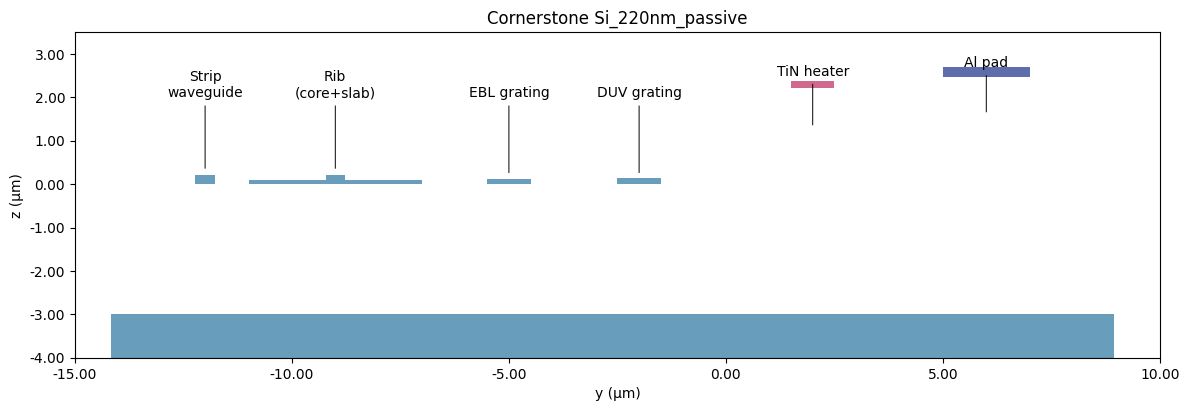

In [8]:
# Plot the cross-section at x=0
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
pf.tidy3d_plot(ref, plot_type="structures", x=0.0, ax=ax)
ax.set_title(tech.name)

ax.annotate("Strip\nwaveguide",   xy=(-12, 0.3), xytext=(-12, 2.0), ha="center",
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7))
ax.annotate("Rib\n(core+slab)",   xy=( -9, 0.3), xytext=( -9, 2.0), ha="center",
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7))
ax.annotate("EBL grating",         xy=( -5, 0.2), xytext=( -5, 2.0), ha="center",
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7))
ax.annotate("DUV grating",         xy=( -2, 0.2), xytext=( -2, 2.0), ha="center",
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7))
ax.annotate("TiN heater",          xy=(  2, 1.3), xytext=(  2, 2.5), ha="center",
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7))
ax.annotate("Al pad",              xy=(  6, 1.6), xytext=(  6, 2.7), ha="center",
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7))
ax.set_xlim(-15, 10)
ax.set_ylim(-4, 3.5)
plt.show()


You can also do an interactive 3D plot of the same component.

In [9]:
pf.tidy3d_plot(ref, plot_type="3d")

## Per-port-spec cross sections

Every PortSpec carries a `path_profiles` tuple describing the in-plane footprint — `(width, offset, gds_layer)` per profile. For **rib** specs we include both core and slab profiles.

In [10]:
for name, spec in tech.ports.items():
    print(f"{name:<16}  width={spec.width:>5} um  z=[{spec.limits[0]:.2f}, {spec.limits[1]:.2f}] um")
    for w, o, layer in spec.path_profiles:
        print(f"      width={w:>5.3f} offset={o:+.3f} layer={tuple(layer)}")


rib_1310nm_TE     width=  4.0 um  z=[-1.00, 1.22] um
      width=0.400 offset=+0.000 layer=(3, 0)
      width=10.400 offset=+0.000 layer=(5, 0)
rib_1550nm_TE     width=  4.0 um  z=[-1.00, 1.22] um
      width=0.450 offset=+0.000 layer=(3, 0)
      width=10.450 offset=+0.000 layer=(5, 0)
strip_1310nm      width=  2.0 um  z=[-1.00, 1.22] um
      width=0.400 offset=+0.000 layer=(3, 0)
strip_1550nm      width=  2.5 um  z=[-1.00, 1.22] um
      width=0.450 offset=+0.000 layer=(3, 0)


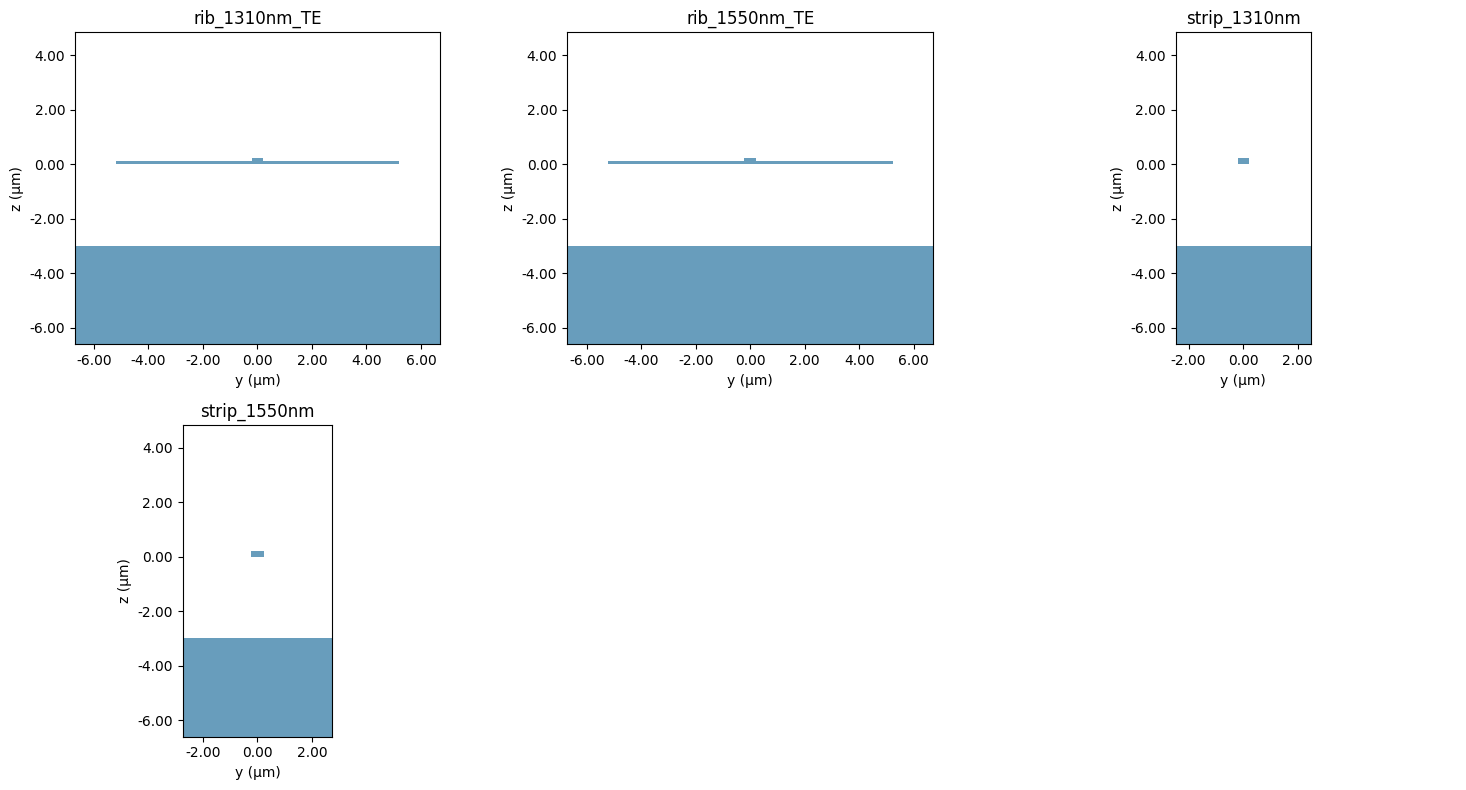

In [11]:
# Visualize each XS as a short reference straight
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, (name, _) in zip(axes, tech.ports.items()):
    s = pf.parametric.straight(port_spec=name, length=20.0, technology=tech)
    pf.tidy3d_plot(s, plot_type="structures", x=10.0, ax=ax)
    ax.set_title(name)
for ax in axes[len(tech.ports):]:
    ax.set_axis_off()
fig.tight_layout()
plt.show()


## What's next

The `component_demo.ipynb` notebook loads the actual foundry GDS files shipped in `cornerstone_forge/library/` and shows how to use them in PhotonForge layouts.